In [14]:
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants")
using BifurcationKit
using Plots
using DifferentialEquations
using LaTeXStrings
using JLD2
using CSV
using DataFrames
using Plots.PlotMeasures

  Activating project at `~/Desktop/envs/ants`


In [58]:
pythonplot() # run once
scalefontsizes(1.5) # run once

In [2]:
function model_7d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    xBdot = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    xTdot = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))

    [
        Sdot
        Bdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

model_7d (generic function with 1 method)

### WRT $k$

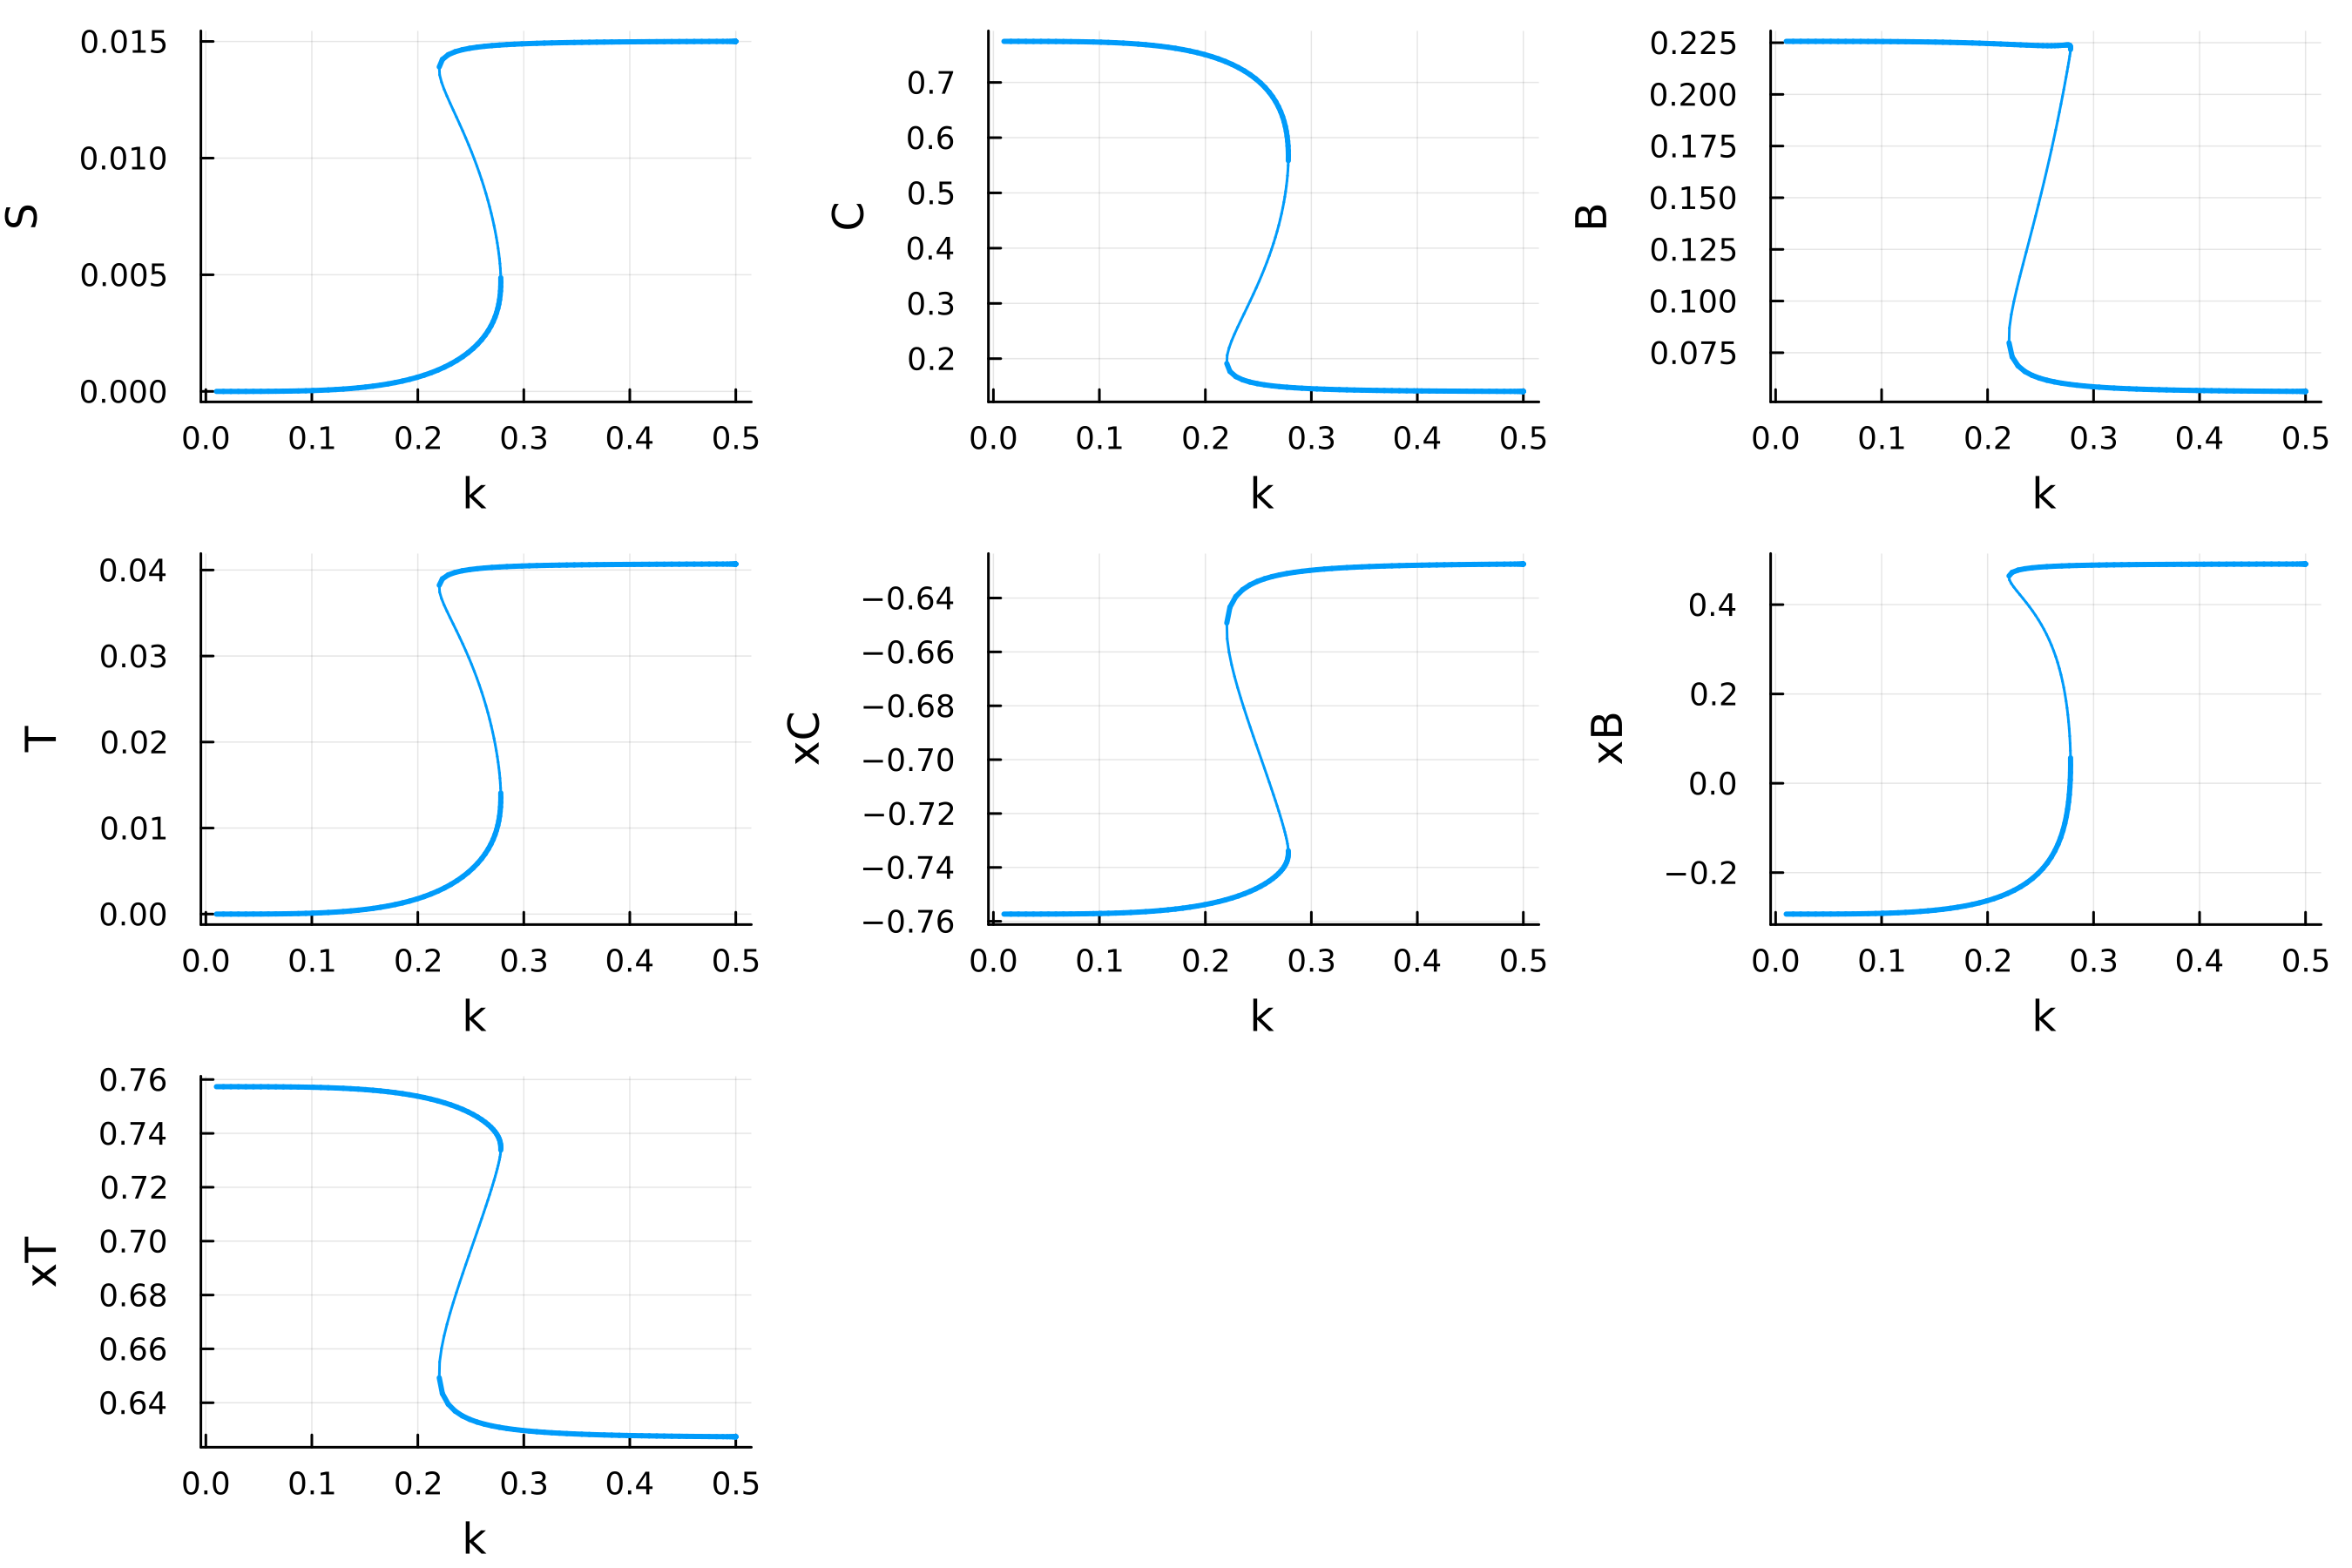

In [20]:
par = (alphaC=5.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par

#u0 = [0.5,0.0,0.0,0.0,0.0,0.0,0.0]
#u0=[0.124884391327275428,0.062413430071074756,0.12482655262389604,0.04150013222529302,-0.0006304423107703057,-0.0006278899118493966,0.0006304423107703055]

u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0]


u_bif_problem = BifurcationProblem(model_7d, u0, par, (@optic _.k),
               record_from_solution = (x, p; k...) -> (S = x[1], B = x[2], C = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]))

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 0.5,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 1,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br,bothside=true)

p1=plot(u_branch_equilibria,vars = (:param,:S))
p2 =plot(u_branch_equilibria,vars = (:param,:C))
p3=plot(u_branch_equilibria,vars = (:param,:B))
p4= plot(u_branch_equilibria,vars = (:param,:T))
p5= plot(u_branch_equilibria,vars = (:param,:xC))
p6= plot(u_branch_equilibria,vars = (:param,:xB))
p7= plot(u_branch_equilibria,vars = (:param,:xT))
FIG = plot(p1,p2,p3,p4,p5,p6,p7,layout = 7,size = (900,600),dpi=300,left_margin = 2mm)
#png(FIG,"hysteresis2")

In [10]:
diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 123
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter k starts at 0.01, ends at 0.5
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at k ≈ +0.01000000,                                                                     step =   0
- #  2,     fold at k ≈ +0.11165114 ∈ (+0.11197091, +0.11197091), |δp|=-1e+00, [    guess], δ = ( 0,  0), step =  23
- #  3,     fold at k ≈ +0.08092584 ∈ (+0.07735809, +0.07735809), |δp|=-1e+00, [    guess], δ = ( 0,  0), step =  45
- #  4, endpoint at k ≈ +0.50000000,                                                                     step = 122


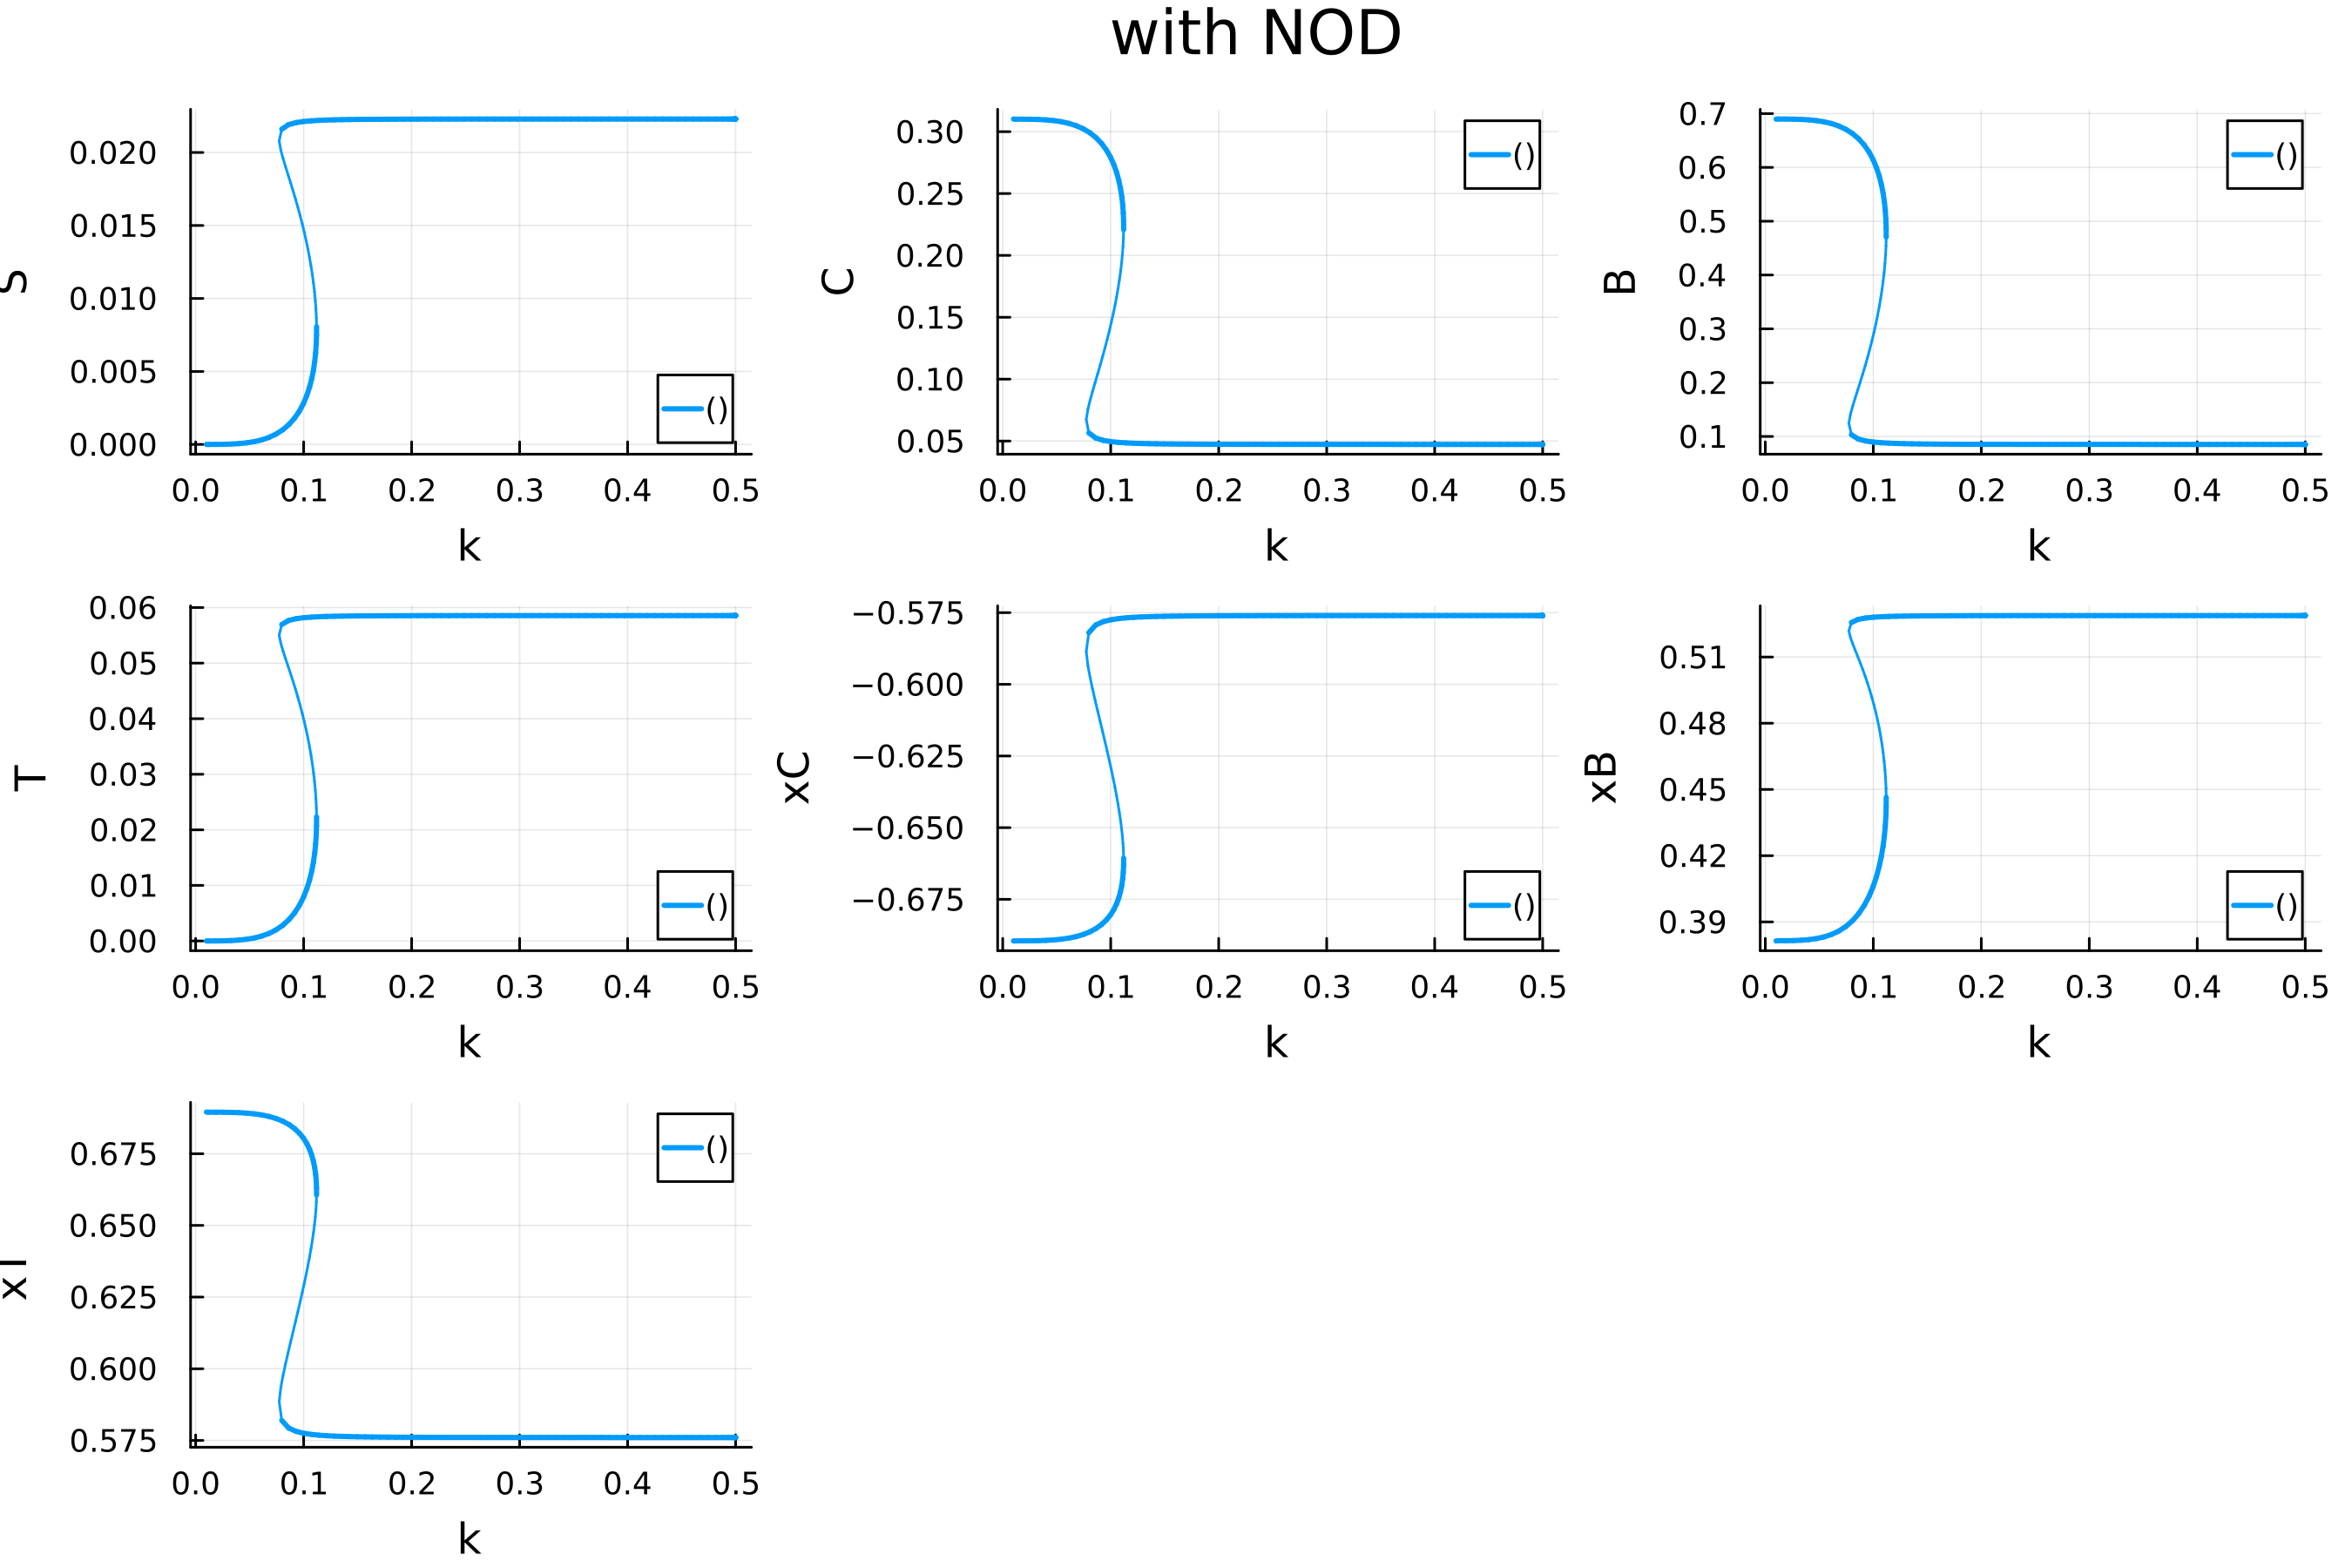

In [13]:
p1=plot(diagram,vars = (:param,:S))
p2 =plot(diagram,vars = (:param,:C))
p3=plot(diagram,vars = (:param,:B))
p4= plot(diagram,vars = (:param,:T))
p5= plot(diagram,vars = (:param,:xC))
p6= plot(diagram,vars = (:param,:xB))
p7= plot(diagram,vars = (:param,:xT))
FIG = plot(p1,p2,p3,p4,p5,p6,p7, layout = 7,size = (900,600),dpi=300,suptitle = "with NOD")

## WRT $u$

In [52]:
par = (alphaC=5.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par


u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0]
#u0 = [0.0,0.0,0.0,0.0,1.0,-1.0,-1.0]

u_bif_problem = BifurcationProblem(model_7d, u0, par, (@optic _.u),
               record_from_solution = (x, p; k...) -> (S = x[1], B = x[2], C = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]))

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 4.0,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 1,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 554
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 0.01, ends at 3.459864795689145
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at u ≈ +0.01000000,                                                                     step =   0
- #  2, endpoint at u ≈ +3.46693586,                                                                     step = 554


In [53]:
par = (alphaC=5.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=1.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma = par


u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0]
u0 = [0.0,0.0,0.0,0.0,1.0,-1.0,-1.0]

u_bif_problem = BifurcationProblem(model_7d, u0, par, (@optic _.u),
               record_from_solution = (x, p; k...) -> (S = x[1], B = x[2], C = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]))

opts_br = ContinuationPar(
    p_min = 0.5, p_max = 4.0,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 1,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

diagram2 = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)


[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 802
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 3.3439897683451147, ends at 3.694844917626027
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at u ≈ +3.35106081,                                                                     step =  -1
- #  2,     fold at u ≈ +0.91402772 ∈ (+0.91324149, +0.91324149), |δp|=-1e+00, [    guess], δ = ( 0,  0), step = 356
- #  3, endpoint at u ≈ +3.70191598,                                                                     step = 802


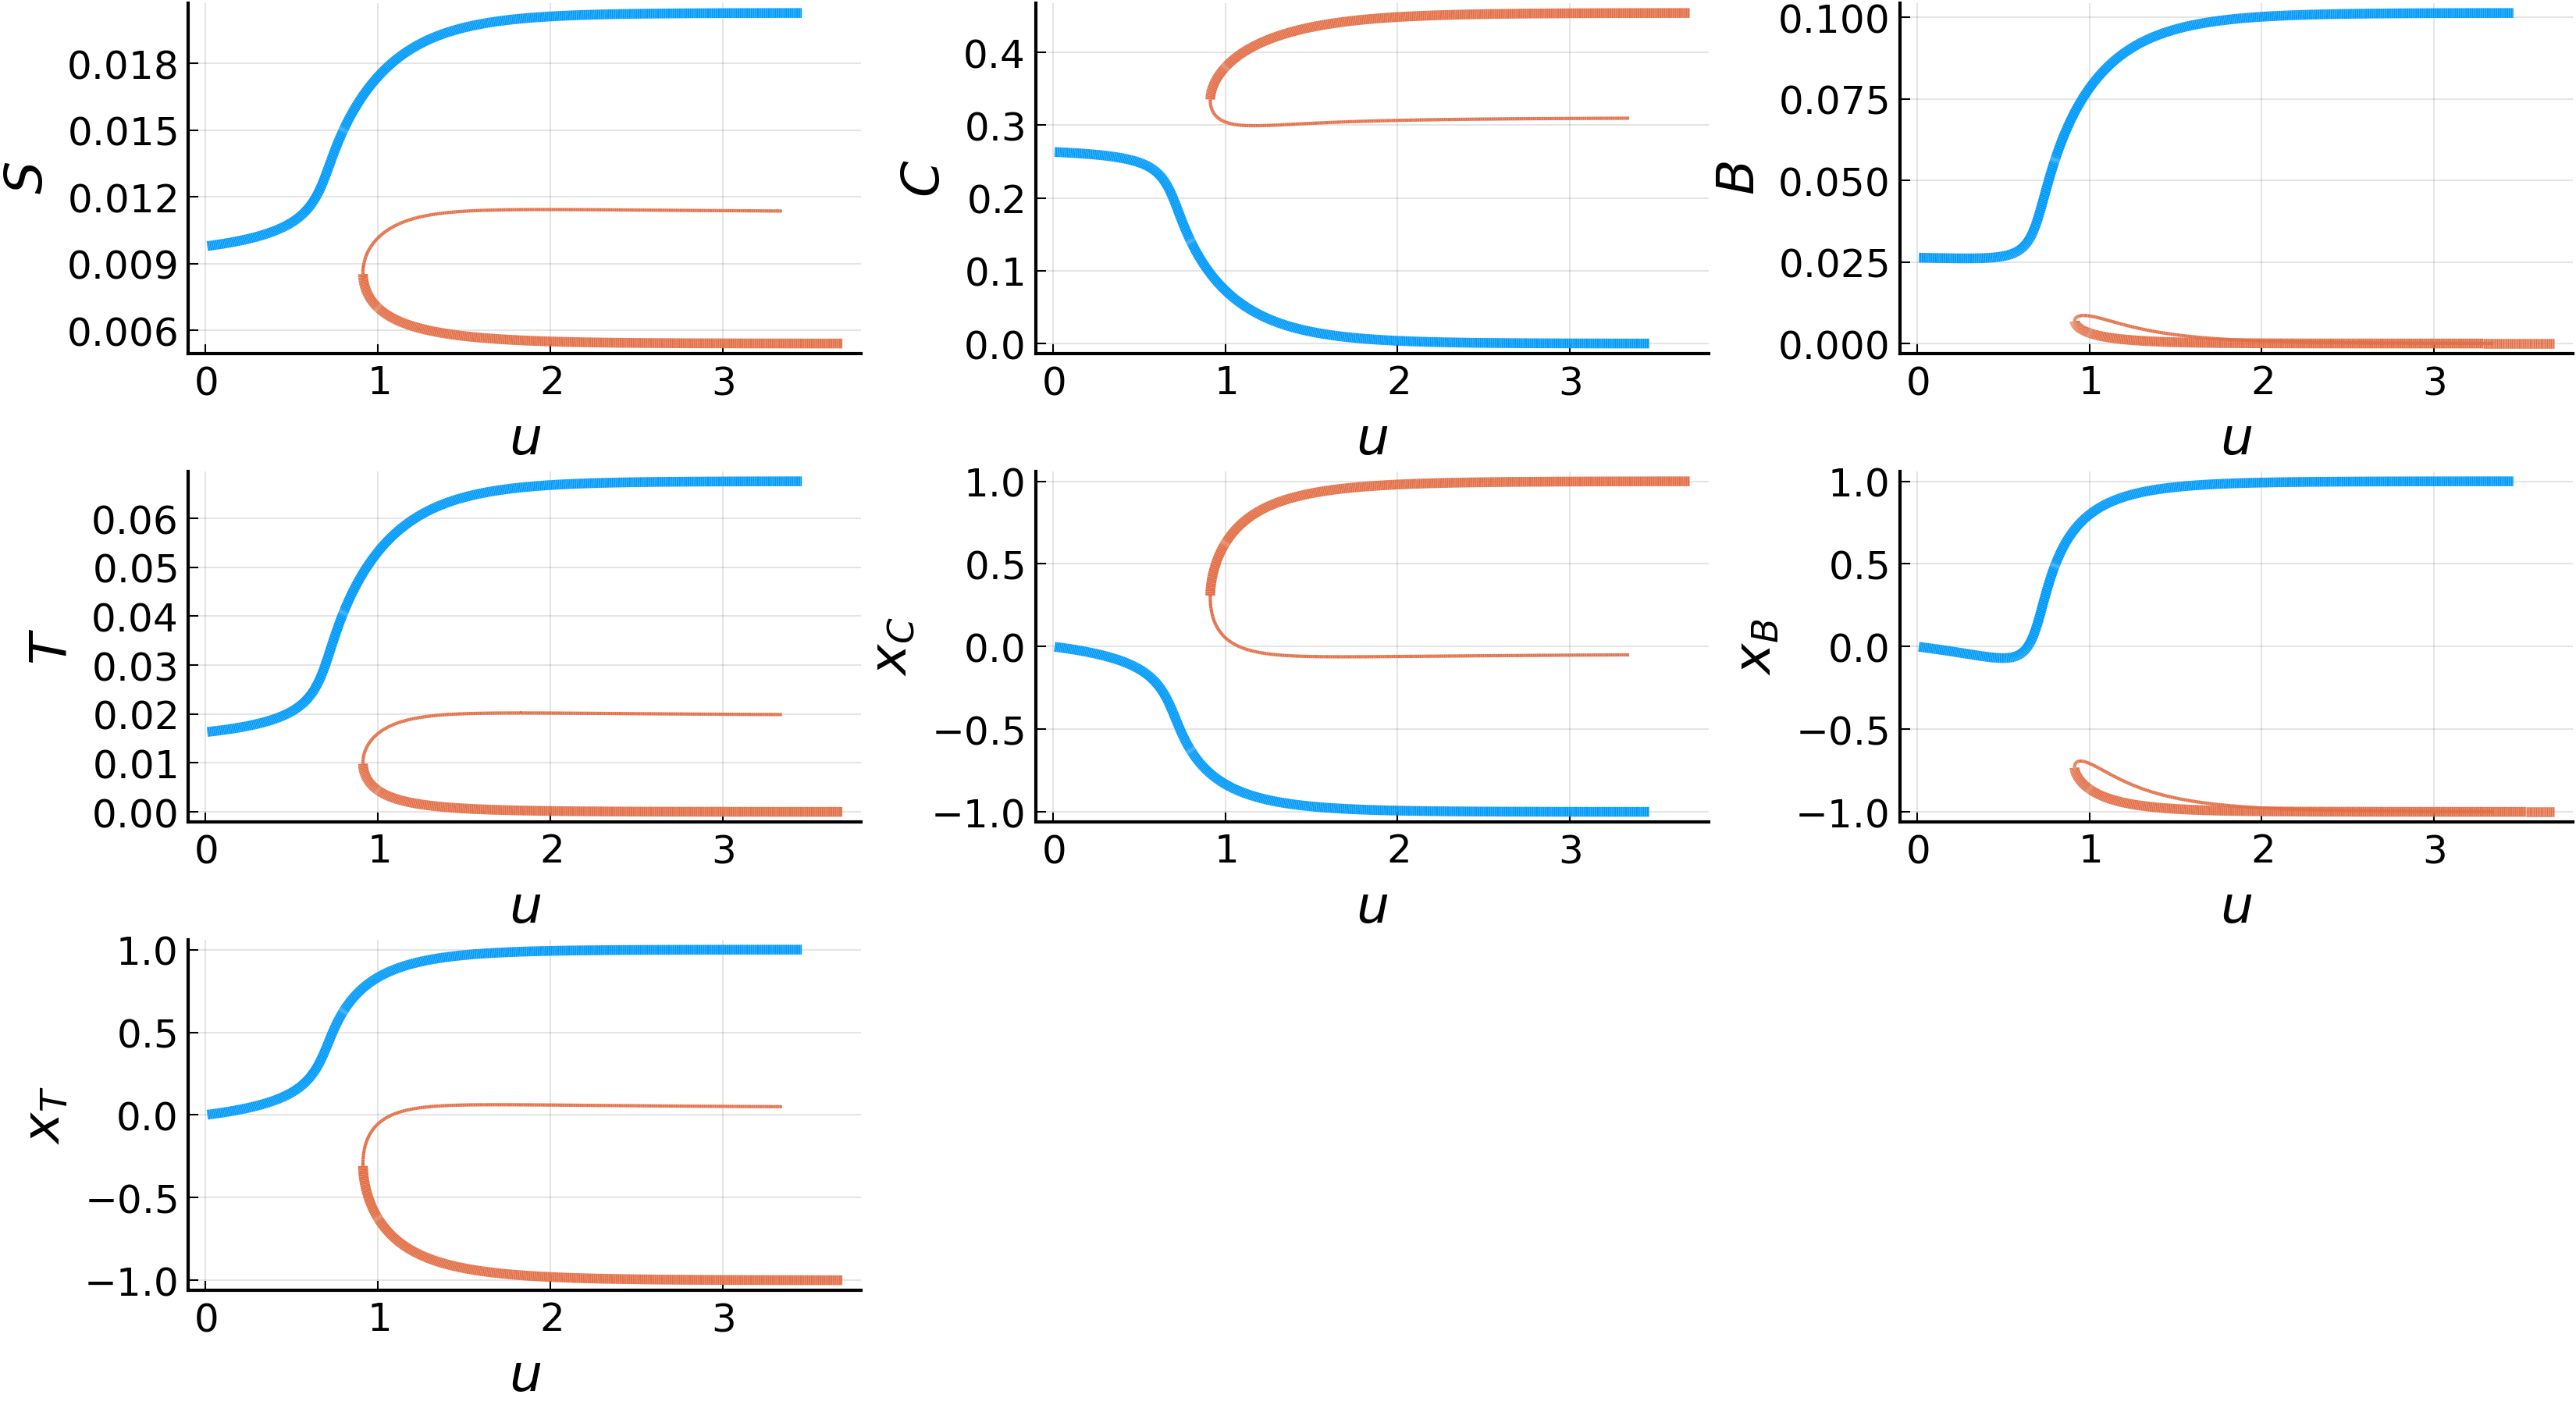

In [63]:
p0 = plot(diagram,vars = (:param,:S),ylabel = L"S",label ="",xlabel = L"u",linewidthstable = 3)
plot!(diagram2,vars = (:param,:S),ylabel = L"S",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)
p1 = plot(diagram,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u",linewidthstable = 3)#,ylims = (0.1,0.2),xlims = (0.5,0.7))
plot!(diagram2,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)#,ylims = (0.1,0.2),xlims = (0.5,0.7)))
p2 = plot(diagram,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u",linewidthstable = 3)
plot!(diagram2,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)
p3 = plot(diagram,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u",linewidthstable = 3)
plot!(diagram2,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)
p4 = plot(diagram,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u",linewidthstable = 3)
plot!(diagram2,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)
p5 = plot(diagram,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u",linewidthstable = 3)
plot!(diagram2,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)
p6 = plot(diagram,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u",linewidthstable = 3)
plot!(diagram2,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = 3)

FIG = plot(p0,p1,p2,p3,p4,p5,p6, layout = 7,size = (1100,600),dpi=300)

In [64]:
png(FIG,"u_long_continuation")

"u_long_continuation.png"